In [1]:
from dask.distributed import Client

client = Client("tcp://127.0.0.1:40410")
client

<Client: 'tcp://127.0.0.1:40410' processes=8 threads=32, memory=503.70 GiB>

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
from xhistogram.xarray import histogram as xhist
from xgcm.grid import Grid
import gsw

import rioxarray
import seaborn as sns

import glob

import gcm_filters

import os.path as op

import warnings
warnings.filterwarnings("ignore")


from matplotlib import ticker
import matplotlib.colors as clr
import matplotlib.pyplot as plt
plt.rcParams['pcolor.shading'] = 'auto'
%matplotlib inline

In [3]:
grav = 9.807
meth = "linear"
ddir = "/storage/tartar/takaya/swot/"

In [19]:
ipass = 9
dsup = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
ipass = 10
dsdn = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
dsup

<xarray.Dataset> Size: 486MB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

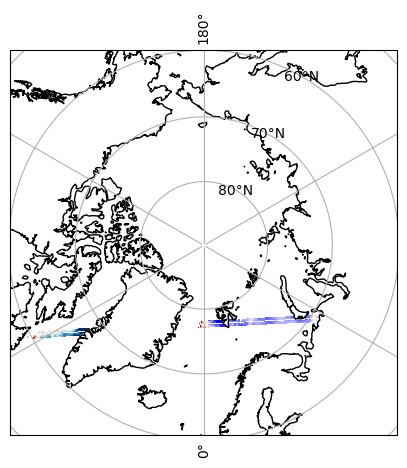

In [21]:
import cartopy.crs as ccrs
import cartopy.util as cutil

fig = plt.figure(figsize=(9,5))

# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.NorthPolarStereo(central_longitude=0,)
                    )
# ax.set_global()
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.pcolormesh(dsup.longitude, dsup.latitude, dsup.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='RdBu_r',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.pcolormesh(dsdn.longitude, dsdn.latitude, dsdn.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='bwr',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.coastlines()
ax.gridlines(draw_labels=True)

In [22]:
ipass = 8
dsup = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
ipass = 7
dsdn = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
dsup

<xarray.Dataset> Size: 486MB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

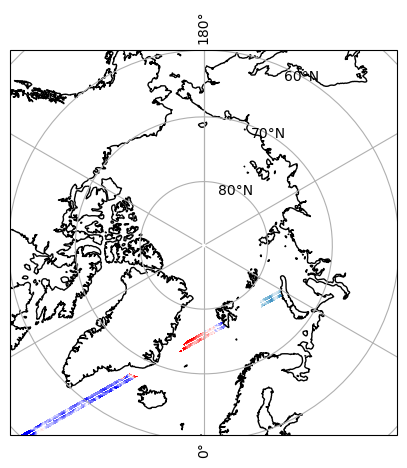

In [23]:
import cartopy.crs as ccrs
import cartopy.util as cutil

fig = plt.figure(figsize=(9,5))

# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.NorthPolarStereo(central_longitude=0,)
                    )
# ax.set_global()
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.pcolormesh(dsup.longitude, dsup.latitude, dsup.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='RdBu_r',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.pcolormesh(dsdn.longitude, dsdn.latitude, dsdn.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='bwr',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.coastlines()
ax.gridlines(draw_labels=True)

In [24]:
ipass = 5
dsup = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
ipass = 6
dsdn = xr.open_zarr(op.join(ddir,"CalVal/geos/Pass%03d/SSHa.zarr" 
                               % ipass)
                      )
dsup

<xarray.Dataset> Size: 486MB
Dimensions:     (cycle_num: 105, num_lines: 9310, num_pixels: 61)
Coordinates:
  * cycle_num   (cycle_num) int64 840B 474 475 476 477 478 ... 575 576 577 578
  * num_lines   (num_lines) int64 74kB 1 2 3 4 5 6 ... 9854 9855 9856 9857 9858
  * num_pixels  (num_pixels) int64 488B 4 5 6 7 8 9 10 ... 58 59 60 61 62 63 64
    latitude    (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
    longitude   (num_lines, num_pixels) float64 5MB dask.array<chunksize=(9310, 61), meta=np.ndarray>
Data variables:
    ssha        (cycle_num, num_lines, num_pixels) float64 477MB dask.array<chunksize=(1, 9310, 61), meta=np.ndarray>

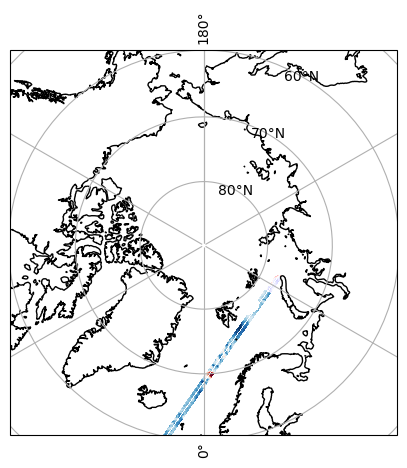

In [26]:
import cartopy.crs as ccrs
import cartopy.util as cutil

fig = plt.figure(figsize=(9,5))

# plot with central longitude 0
ax = fig.add_subplot(1, 1, 1,
                     projection=ccrs.NorthPolarStereo(central_longitude=0,)
                    )
# ax.set_global()
ax.set_extent([-180, 180, 60, 90], ccrs.PlateCarree())
ax.pcolormesh(dsup.longitude, dsup.latitude, dsup.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='RdBu_r',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.pcolormesh(dsdn.longitude, dsdn.latitude, dsdn.ssha.isel(cycle_num=1),
              transform=ccrs.PlateCarree(), 
              cmap='bwr',
              vmin=-.1, vmax=.1,
              rasterized=True)
ax.coastlines()
ax.gridlines(draw_labels=True)